# Walkthrough: NYC congestion pricing KPI pipeline
Reads the DuckDB warehouse built by `python -m tlc_pipeline.pipeline`. Each section maps to one grading axis: **sources → retrieval → validation → model/metrics → pipeline**.

In [1]:
import json, os, sys
from pathlib import Path
try:
    import duckdb, pandas as pd
except ImportError as e:
    raise ImportError(f'{e}. This kernel is {sys.executable}; select the Python where you ran '
                      '`pip install -r requirements.txt`, or run: %pip install duckdb pandas pyarrow') from None

# Find the project root however the notebook was opened (VS Code, Jupyter, any working dir).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'tlc_pipeline').is_dir())
os.chdir(ROOT / 'notebooks')
DB = ROOT / 'data' / 'warehouse' / 'tlc.duckdb'
if not DB.exists():
    raise FileNotFoundError(f'{DB} not found. Run the pipeline first, from {ROOT}: python -m tlc_pipeline.pipeline')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
try:
    con = duckdb.connect(str(DB), read_only=True)
except duckdb.IOException as e:
    raise RuntimeError('Warehouse is locked. Wait for the pipeline to finish, or restart any other kernel '
                       'that has it open, then rerun this cell.') from e
q = lambda sql: con.sql(sql).df()
print('project root:', ROOT)

project root: C:\Users\Asus\Documents\3rd year\term 1\FDE-Manan-Gupta\nyc-tlc-cbd-pipeline\assignment-2


## 1. Retrieval: proof of completeness
Every raw input is in `data/raw/manifest.json`, with its checksum and what the source declared.

In [2]:
m = json.load(open('../data/raw/manifest.json'))
pd.DataFrame([{'file': k, **{c: v.get(c) for c in ['bytes','declared_bytes','rows_in_parquet_metadata','records','api_count','pages']}} for k, v in m.items()])

,file,bytes,declared_bytes,rows_in_parquet_metadata,records,api_count,pages
0,data/raw/api/mta_cbd_speeds.json,NaN,NaN,NaN,213.0,213.0,5.0
1,data/raw/api/mta_cbd_taxi_zones.json,NaN,NaN,NaN,38.0,38.0,1.0
2,data/raw/api/open_meteo_2024-01.json,NaN,NaN,NaN,31.0,NaN,NaN
3,data/raw/api/open_meteo_2025-01.json,NaN,NaN,NaN,31.0,NaN,NaN
4,data/raw/tlc/taxi_zone_lookup.csv,12331.0,-1.0,NaN,NaN,NaN,NaN
5,data/raw/tlc/yellow_tripdata_2024-01.parquet,49961641.0,49961641.0,2964624.0,NaN,NaN,NaN
6,data/raw/tlc/yellow_tripdata_2025-01.parquet,59158238.0,59158238.0,3475226.0,NaN,NaN,NaN


In [3]:
q("select source_month, count(*) as n_rows, min(tpep_pickup_datetime) min_pickup, max(tpep_pickup_datetime) max_pickup from raw_trips group by 1 order by 1")

,source_month,n_rows,min_pickup,max_pickup
0,2024-01,2964624,2002-12-31 22:59:39,2024-02-01 00:01:15
1,2025-01,3475226,2024-12-31 20:47:55,2025-02-01 00:00:44


## 2. Profiling the raw data (before any rule)
What the source looks like as delivered.

In [4]:
q("""select source_month,
  count(*) filter (where passenger_count is null) as null_passenger_count,
  max(trip_distance) as max_distance_mi, max(total_amount) as max_total, min(total_amount) as min_total,
  count(*) filter (where tpep_dropoff_datetime <= tpep_pickup_datetime) as nonpositive_duration,
  count(cbd_congestion_fee) as rows_with_fee_column
from raw_trips group by 1 order by 1""")

,source_month,null_passenger_count,max_distance_mi,max_total,min_total,nonpositive_duration,rows_with_fee_column
0,2024-01,140162,312722.30,5000.00,-900.0,870,0
1,2025-01,540149,276423.57,863380.37,-901.0,2051,3475226


**Finding: missing metadata is concentrated in `payment_type = 0`.** Those rows have no passenger count or rate code, but their timestamps and zones look normal, so they are kept (rule R11 only warns).

In [5]:
q("select source_month, payment_type, count(*) as n, count(passenger_count) with_passenger_count from raw_trips group by all order by all")

,source_month,payment_type,n,with_passenger_count
0,2024-01,0,140162,0
1,2024-01,1,2319046,2319046
2,2024-01,2,439191,439191
3,2024-01,3,19597,19597
4,2024-01,4,46628,46628
5,2025-01,0,540149,0
6,2025-01,1,2444393,2444393
7,2025-01,2,390429,390429
8,2025-01,3,23773,23773
9,2025-01,4,76481,76481


**Finding: vendor 7 reports pickup = dropoff on every trip**, so it has no usable durations. Rule R05 catches this without any vendor-specific code.

In [6]:
q("select source_month, VendorID, count(*) as n, count(*) filter (where tpep_dropoff_datetime = tpep_pickup_datetime) zero_duration from raw_trips group by all order by all")

,source_month,VendorID,n,zero_duration
0,2024-01,1,729732,707
1,2024-01,2,2234632,103
2,2024-01,6,260,4
3,2025-01,1,753671,640
4,2025-01,2,2719860,76
5,2025-01,6,489,5
6,2025-01,7,1206,1206


## 3. Validation: rules and gates
Rows are **flagged, never deleted**. Severity decides which metrics a row may feed.

In [7]:
q("select rule_id, rule, severity, source_month, rows_flagged, round(100*share, 2) as pct from dq_results order by rule_id, source_month")

,rule_id,rule,severity,source_month,rows_flagged,pct
0,R01,out_of_month,exclude_all,2024-01,18,0.00
1,R01,out_of_month,exclude_all,2025-01,22,0.00
2,R02,duplicate,exclude_all,2024-01,0,0.00
3,R02,duplicate,exclude_all,2025-01,0,0.00
4,R03,reversal_record,exclude_all,2024-01,35504,1.20
5,R03,reversal_record,exclude_all,2025-01,63037,1.81
6,R04,unknown_zone,exclude_all,2024-01,31527,1.06
7,R04,unknown_zone,exclude_all,2025-01,28357,0.82
8,R05,bad_duration,exclude_speed,2024-01,37104,1.25
9,R05,bad_duration,exclude_speed,2025-01,41488,1.19


In [8]:
q("select source_month, gate, passed, detail from gate_results where run_id = (select max_by(run_id, finished_at) from run_log) order by 1, 2")

,source_month,gate,passed,detail
0,2024-01,every_day_present,True,"31/31 days; lowest 2024-01-07 with 67,543 trip..."
1,2024-01,out_of_month_share,True,0.0006% of rows outside the month (limit 0.10%)
2,2024-01,rows_match_source_file,True,"parquet metadata=2,964,624 raw_trips=2,964,624..."
3,2024-01,speed_ineligible_share,True,4.47% of trips unusable for speed (limit 15%)
4,2024-01,weather_complete,True,31/31 days of weather
5,2025-01,every_day_present,True,"31/31 days; lowest 2025-01-05 with 79,624 trip..."
6,2025-01,out_of_month_share,True,0.0006% of rows outside the month (limit 0.10%)
7,2025-01,rows_match_source_file,True,"parquet metadata=3,475,226 raw_trips=3,475,226..."
8,2025-01,speed_ineligible_share,True,5.75% of trips unusable for speed (limit 15%)
9,2025-01,weather_complete,True,31/31 days of weather


**Semantics check on the fee:** the fee appears on trips that neither start nor end in the zone. That is correct: the toll applies to trips that *pass through* the zone. So it is not flagged as an error.

In [9]:
q("select trip_scope, count(*) as trips, round(100*avg((cbd_congestion_fee > 0)::int), 1) pct_charged from fact_trip_clean where source_month = '2025-01' and is_valid_trip and pickup_at >= date '2025-01-05' group by 1 order by 1")

,trip_scope,trips,pct_charged
0,cbd_internal,1291875,99.3
1,cbd_touch,900085,97.0
2,outside,844265,9.2


## 4. Model
Entities: `dim_zone`, `dim_date` (weekday, holiday, weather, period). Event: `fact_trip` (pickup → dropoff). Intervention: `period` and `cbd_congestion_fee`. `trip_event` is the long event view.

In [10]:
q("select * from dim_zone where in_cbd limit 5")

,location_id,borough,zone,service_zone,in_cbd
0,4,Manhattan,Alphabet City,Yellow Zone,True
1,12,Manhattan,Battery Park,Yellow Zone,True
2,13,Manhattan,Battery Park City,Yellow Zone,True
3,45,Manhattan,Chinatown,Yellow Zone,True
4,48,Manhattan,Clinton East,Yellow Zone,True


In [11]:
q("select period, count(*) as n_days, count(*) filter (where in_window) window_days, count(*) filter (where in_window and is_wet) wet_window_days from dim_date group by 1")

,period,n_days,window_days,wet_window_days
0,after,27,19,2
1,before,35,18,8


In [12]:
q("select event, date_part('hour', event_at) as hour, count(*) as events from trip_event where source_month = '2025-01' and location_id = 161 group by all order by event, hour limit 10")

,event,hour,events
0,dropoff,0,1120
1,dropoff,1,750
2,dropoff,2,380
3,dropoff,3,257
4,dropoff,4,237
5,dropoff,5,1118
6,dropoff,6,3066
7,dropoff,7,7055
8,dropoff,8,9713
9,dropoff,9,9684


## 5. Metrics and the judgement call
The raw KPI (M1) rises, but the before window had many more wet days. Comparing dry days only, inside the zone against outside it, gives the net effect.

In [13]:
kpi = pd.read_csv('../output/kpi_before_after.csv')
kpi[['metric_id','metric','unit','before','after','change_pct','direction']].round(2)

,metric_id,metric,unit,before,after,change_pct,direction
0,M1,"Median CBD trip speed, weekday peak",mph,7.74,7.89,1.86,better
1,M2,Share of CBD peak trips crawling (<5 mph),%,12.79,11.71,-8.39,better
2,M3,"90th pct travel time per mile, CBD peak",min/mile,12.80,12.52,-2.20,better
3,M4,CBD-internal taxi trips per weekday,trips/day,38419.28,47651.63,24.03,NaN
4,M5,CBD trips charged the congestion fee,%,NaN,98.37,NaN,NaN
5,C1,Control: median speed of trips outside the CBD...,mph,9.30,9.11,-2.07,NaN
6,C2,Control: M1 on dry days only,mph,7.83,7.87,0.50,better
7,C3,Control: MTA published CBD taxi/FHV speed (who...,mph,9.31,9.66,3.76,better
8,C4,Control: C1 on dry days only,mph,9.41,9.11,-3.27,NaN


In [14]:
t = kpi.set_index('metric_id')
print(f"Net effect (C2 - C4): {t.loc['C2','change_pct'] - t.loc['C4','change_pct']:+.1f} percentage points")
print(f"MTA published CBD speed change (C3): {t.loc['C3','change_pct']:+.1f}%")

Net effect (C2 - C4): +3.8 percentage points
MTA published CBD speed change (C3): +3.8%


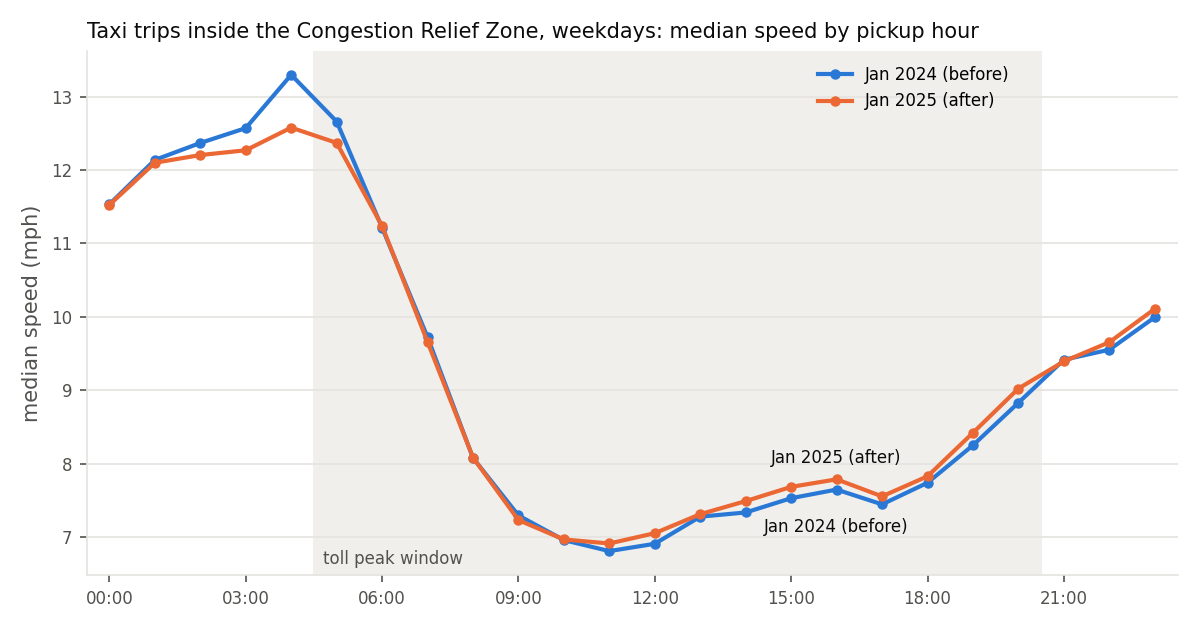

In [15]:
from IPython.display import Image
Image('../output/cbd_speed_by_hour.png')

## 6. Pipeline run history
Each run is logged. Months that fail a gate are quarantined, not published.

In [16]:
q("select run_id, started_at, finished_at, status, message from run_log order by started_at desc limit 5")

,run_id,started_at,finished_at,status,message
0,3683e2fa,2026-09-27 14:08:54.630246,2026-09-27 14:09:14.442231,success,"published ['2024-01', '2025-01']"
1,b110f0b5,2026-09-27 13:54:49.731382,2026-09-27 13:55:19.803187,success,"published ['2024-01', '2025-01']"
2,446e87d5,2026-09-25 12:14:17.893144,2026-09-25 12:15:08.605177,success,"published ['2024-01', '2025-01']"
3,52a4441f,2026-09-25 12:05:05.787411,2026-09-25 12:05:32.355693,success,"published ['2024-01', '2025-01']"
4,f6d72f92,2026-09-25 11:54:24.352095,2026-09-25 11:54:49.655776,success,"published ['2024-01', '2025-01']"


In [17]:
q("select * from month_status order by source_month")

,source_month,run_id,status,detail,updated_at
0,2024-01,3683e2fa,published,,2026-09-27 14:09:08.632934
1,2025-01,3683e2fa,published,,2026-09-27 14:09:13.231856
2,2030-01,9bfabdd4,failed,HEAD https://d37ci6vzurychx.cloudfront.net/tri...,2026-09-25 11:54:07.624388
